In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import scipy.stats as st
from pathlib import Path

# Rating vs BoxOffice Revenue
## How do different types of movie ratings relate to box office success?

This project explores whether higher movie ratings are associated with greater box office revenue.

The data used in this analysis comes from Rotten Tomatoes and IMDb, two of the most popular movie rating websites. Their ratings and audience metrics will be analyzed and compared to examine whether the two platforms produce similar results and which one better reflects real-world success measured through box office revenue.

In [2]:
DATA_DIR = Path("data")
DATA_FILE = DATA_DIR / "imdb-movies-from-1960-to-2023.csv"

if not DATA_FILE.exists():
    DATA_DIR.mkdir(exist_ok=True)
    raise FileNotFoundError(
        "Dataset not found. Download it from Kaggle and place it in the data/ folder:\n"
        "KAGGLE_LINK_HERE: https://www.kaggle.com/datasets/raedaddala/imdb-movies-from-1960-to-2023/data"
    )

In [3]:
movies_data = pd.read_csv(DATA_FILE)

In [4]:
movies_data

,id,title,duration,mpa,rating,votes,méta_score,description,movie_link,writers,...,opening_weekend_gross,gross_worldwide,gross_us_canada,release_date,countries_origin,filming_locations,production_companies,awards_content,genres,languages
0,tt0080125,West Indies,1h 50m,NaN,7.1,301,NaN,This vast musical fresco covers hundreds of ye...,https://www.imdb.com/title/tt0080125/,"['Daniel Boukman', 'Med Hondo']",...,NaN,NaN,NaN,1985-03-18,"['France', 'Algeria', 'Mauritania']",NaN,"['Les Films Soleil O', 'Office National de Cin...",NaN,"['Drama', 'Musical']",['French']
1,tt0249500,Estafa de amor,1h 33m,NaN,6.7,14,NaN,NaN,https://www.imdb.com/title/tt0249500/,"['Caridad Bravo Adams', 'Miguel M. Delgado', '...",...,NaN,NaN,NaN,1956-09-27,['Mexico'],NaN,['Filmadora Chapultepec'],NaN,['Drama'],['Spanish']
2,tt0054151,Brother,1h 38m,NaN,6.9,498,NaN,Set in 1926 when Japanese tradition was much s...,https://www.imdb.com/title/tt0054151/,"['Aya Kôda', 'Yôko Mizuki']",...,NaN,NaN,NaN,1960-11-01,['Japan'],NaN,['Daiei'],NaN,['Drama'],['Japanese']
3,tt6136430,Ferrante Fever,1h 14m,NaN,6.3,196,52.0,"Hillary Clinton, Roberto Saviano, Jonathan Fra...",https://www.imdb.com/title/tt6136430/,"['Laura Buffoni', 'Giacomo Durzi']",...,"$3,509","$14,518","$11,137",2019-03-08,"['Italy', 'France']","['Manhattan, New York City, New York, USA']","['Malìa', 'Rai Cinema', 'QMI']",NaN,['Documentary'],"['Italian', 'French', 'English']"
4,tt30395619,Demon Slayer: Kimetsu No Yaiba - To the Hashir...,1h 44m,R,7.1,8.3K,61.0,Tanjiro undergoes rigorous training with the S...,https://www.imdb.com/title/tt30395619/,['Koyoharu Gotouge'],...,"$11,505,414","$44,354,825","$17,657,658",2024-02-23,['Japan'],NaN,"['Shueisha', 'Aniplex', 'Ufotable']",NaN,"['Anime', 'Dark Fantasy', 'Shōnen', 'Supernatu...",['Japanese']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63244,tt0799915,Air Guitar Nation,1h 21m,R,7.1,1.4K,72.0,"The guitars may be fake, but the talent is rea...",https://www.imdb.com/title/tt0799915/,"['Dan Crane', 'David S. Jung', 'Hadia Ackerman']",...,"$7,035","$79,770","$71,471",2007-10-06,['United States'],"['Los Angeles, California, USA']","['Docurama', 'Magical Elves Productions']",NaN,"['Biography', 'Documentary', 'Music']",['English']
63245,tt0069876,La choca,1h 34m,NaN,6.3,123,NaN,"Martin lives in a mountain hut with his wife, ...",https://www.imdb.com/title/tt0069876/,"['Alfonso Díaz Bullard', 'Emilio Fernández']",...,NaN,NaN,NaN,1974-09-05,['Mexico'],"['Santa Sofia, Oaxaca, Mexico']","['Conacite Uno', 'Estudios Churubusco Azteca S...",NaN,"['Drama', 'Western']",['Spanish']
63246,tt0087027,Camila,1h 45m,R,6.9,1.6K,NaN,"In 1840's Buenos Aires, Argentina, a beautiful...",https://www.imdb.com/title/tt0087027/,"['María Luisa Bemberg', 'Beda Docampo Feijóo',...",...,NaN,NaN,NaN,1985-03-15,"['Argentina', 'Spain']","['Chascomús, Buenos Aires Province, Argentina.']","['GEA Producciones', 'Impala']",NaN,"['Period Drama', 'Drama', 'Romance']",['Spanish']
63247,tt0095955,Ram-Avtar,2h 50m,NaN,4.6,280,NaN,Ram and Avtar are both childhood best friends....,https://www.imdb.com/title/tt0095955/,"['Anwar Khan', 'Mansood Saharanpuri', 'Khalid ...",...,NaN,NaN,NaN,1988-01-01,['India'],['India'],['Kapleshwar Pictures'],NaN,"['Action', 'Drama', 'Romance']",['Hindi']


In [5]:
movies_data.dtypes

id                        object
title                     object
duration                  object
mpa                       object
rating                   float64
votes                     object
méta_score               float64
description               object
movie_link                object
writers                   object
directors                 object
stars                     object
budget                    object
opening_weekend_gross     object
gross_worldwide           object
gross_us_canada           object
release_date              object
countries_origin          object
filming_locations         object
production_companies      object
awards_content           float64
genres                    object
languages                 object
dtype: object

In [6]:
movies_data.isnull().sum()

id                           0
title                        0
duration                  2075
mpa                      22022
rating                    4068
votes                     4068
méta_score               47716
description               2360
movie_link                   0
writers                    269
directors                   51
stars                      344
budget                   47890
opening_weekend_gross    46412
gross_worldwide          42527
gross_us_canada          43705
release_date                 0
countries_origin            99
filming_locations        16854
production_companies      1973
awards_content           63249
genres                     787
languages                  330
dtype: int64

### Cleanup

In [7]:
movies_data['votes'] = pd.to_numeric(movies_data['votes'], errors='coerce')

In [8]:
movies_data['votes']

0        301.0
1         14.0
2        498.0
3        196.0
4          NaN
         ...  
63244      NaN
63245    123.0
63246      NaN
63247    280.0
63248      NaN
Name: votes, Length: 63249, dtype: float64

In [9]:
movies_data['duration']

0        1h 50m
1        1h 33m
2        1h 38m
3        1h 14m
4        1h 44m
          ...  
63244    1h 21m
63245    1h 34m
63246    1h 45m
63247    2h 50m
63248    1h 41m
Name: duration, Length: 63249, dtype: object

In [10]:
movies_data['duration'] = (
    movies_data['duration']
    .str.extract(r'(?:(\d+)h)?\s*(?:(\d+)m)?')
    .fillna(0)
    .astype(int)
    .pipe(lambda x: x[0]*60 + x[1])
)

In [11]:
movies_data['duration']

0        110
1         93
2         98
3         74
4        104
        ... 
63244     81
63245     94
63246    105
63247    170
63248    101
Name: duration, Length: 63249, dtype: int64

In [12]:
movies_data['budget']

0                           NaN
1                           NaN
2                           NaN
3          €150,000 (estimated)
4                           NaN
                  ...          
63244                       NaN
63245                       NaN
63246                       NaN
63247                       NaN
63248    $6,000,000 (estimated)
Name: budget, Length: 63249, dtype: object

In [13]:
def clean_up_money(var):
    return (
        movies_data[var]
        .astype(str)
        .str.replace(r'\(.*?\)', '', regex=True)
        .str.replace(r'[^\d.]', '', regex=True)
        .replace('', None)                      
        .astype(float)
    )

In [14]:
movies_data['budget'] = clean_up_money('budget')

In [15]:
movies_data['budget']

0              NaN
1              NaN
2              NaN
3         150000.0
4              NaN
           ...    
63244          NaN
63245          NaN
63246          NaN
63247          NaN
63248    6000000.0
Name: budget, Length: 63249, dtype: float64

In [16]:
movies_data['opening_weekend_gross'] = clean_up_money('opening_weekend_gross')

In [17]:
movies_data['opening_weekend_gross']

0               NaN
1               NaN
2               NaN
3            3509.0
4        11505414.0
            ...    
63244        7035.0
63245           NaN
63246           NaN
63247           NaN
63248      202342.0
Name: opening_weekend_gross, Length: 63249, dtype: float64

In [18]:
movies_data['gross_worldwide']

0                NaN
1                NaN
2                NaN
3            $14,518
4        $44,354,825
            ...     
63244        $79,770
63245            NaN
63246            NaN
63247            NaN
63248       $408,159
Name: gross_worldwide, Length: 63249, dtype: object

In [19]:
movies_data['gross_worldwide'] = clean_up_money('gross_worldwide')

In [20]:
movies_data['gross_worldwide']

0               NaN
1               NaN
2               NaN
3           14518.0
4        44354825.0
            ...    
63244       79770.0
63245           NaN
63246           NaN
63247           NaN
63248      408159.0
Name: gross_worldwide, Length: 63249, dtype: float64

In [21]:
movies_data['gross_us_canada'] = clean_up_money('gross_us_canada')

In [22]:
movies_data['gross_us_canada']

0               NaN
1               NaN
2               NaN
3           11137.0
4        17657658.0
            ...    
63244       71471.0
63245           NaN
63246           NaN
63247           NaN
63248      408159.0
Name: gross_us_canada, Length: 63249, dtype: float64

In [23]:
movies_data['budget'].isna().sum() / len(movies_data)

np.float64(0.7571661212034972)

In [24]:
movies_data[movies_data['budget'].isna()][['title', 'budget', 'movie_link', 'release_date']].head(10)

,title,budget,movie_link,release_date
0,West Indies,NaN,https://www.imdb.com/title/tt0080125/,1985-03-18
1,Estafa de amor,NaN,https://www.imdb.com/title/tt0249500/,1956-09-27
2,Brother,NaN,https://www.imdb.com/title/tt0054151/,1960-11-01
4,Demon Slayer: Kimetsu No Yaiba - To the Hashir...,NaN,https://www.imdb.com/title/tt30395619/,2024-02-23
5,The Toxic Avenger,NaN,https://www.imdb.com/title/tt1633359/,2025-08-29
6,Score,NaN,https://www.imdb.com/title/tt4207112/,2017-09-05
7,Aces and Eights,NaN,https://www.imdb.com/title/tt0027255/,1936-06-06
8,Rakkauden risti,NaN,https://www.imdb.com/title/tt0038870/,1946-03-08
10,I zoi mou arhizei me sena,NaN,https://www.imdb.com/title/tt0290943/,1961-10-27
13,The Nina B. Affair,NaN,https://www.imdb.com/title/tt0054605/,1961-06-07


In [25]:
movies_data[['rating',
             'votes',
             'opening_weekend_gross',
             'gross_worldwide',
             'gross_us_canada']].describe()

,rating,votes,opening_weekend_gross,gross_worldwide,gross_us_canada
count,59181.000000,32666.000000,1.683700e+04,2.072200e+04,1.954400e+04
mean,6.162731,283.318833,4.940692e+06,3.557924e+07,1.707114e+07
std,1.070630,262.340657,1.464693e+07,1.173666e+08,4.715488e+07
min,1.000000,5.000000,1.100000e+01,1.000000e+00,1.000000e+00
25%,5.500000,68.000000,1.122700e+04,9.519100e+04,6.506775e+04
50%,6.300000,192.000000,8.451200e+04,1.665806e+06,7.309035e+05
75%,6.900000,437.000000,3.424702e+06,1.803175e+07,1.209672e+07
max,10.000000,999.000000,3.571150e+08,2.923711e+09,9.366622e+08


### Data Visualization

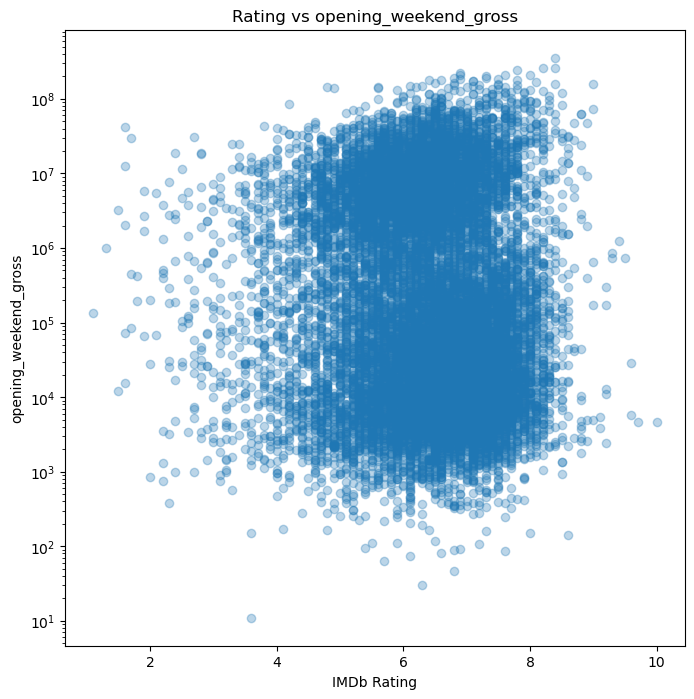

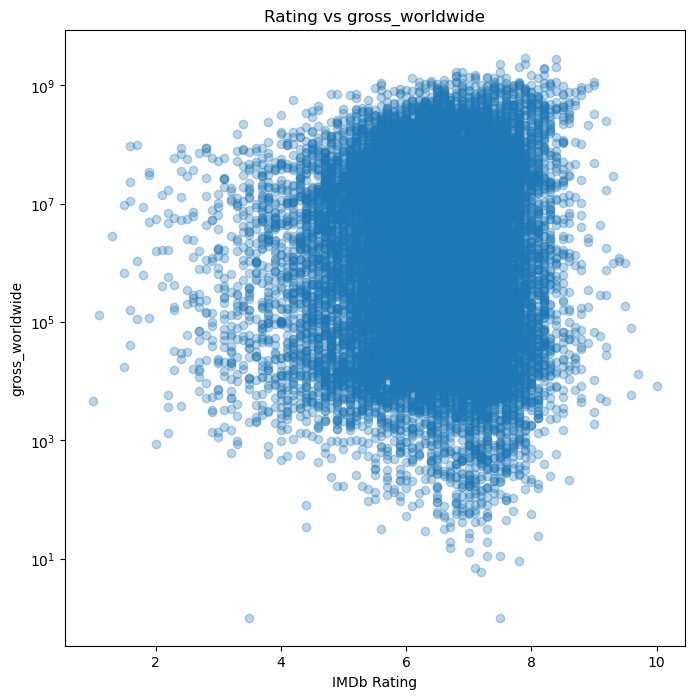

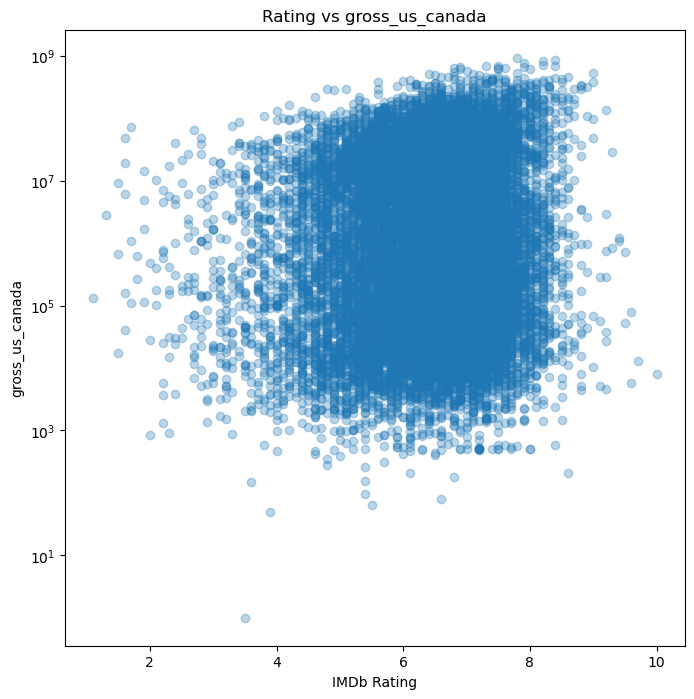

In [26]:
columns = [
    'opening_weekend_gross',
    'gross_worldwide',
    'gross_us_canada'
]

for col in columns:
    plt.figure(figsize=(8,8))

    plt.scatter(
        movies_data['rating'],
        movies_data[col],
        alpha=0.3
    )

    plt.yscale('log')

    plt.title(f'Rating vs {col}')
    plt.xlabel('IMDb Rating')
    plt.ylabel(col)

    plt.show()


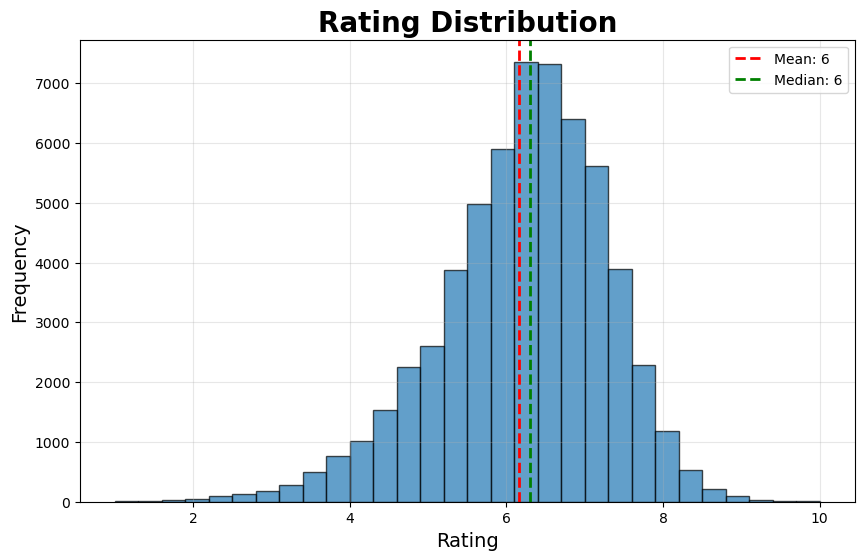

In [27]:
data = movies_data['rating'].dropna()

mean_value = data.mean()
median_value = data.median()

plt.figure(figsize=(10,6))

plt.hist(data, bins=30, edgecolor='black', alpha=0.7)

plt.axvline(mean_value,
            color='red',
            linestyle='--',
            linewidth=2,
            label=f'Mean: {mean_value:,.0f}')

plt.axvline(median_value,
            color='green',
            linestyle='--',
            linewidth=2,
            label=f'Median: {median_value:,.0f}')

plt.title('Rating Distribution',
          fontsize=20,
          fontweight='bold')

plt.xlabel('Rating', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

plt.grid(alpha=0.3)

plt.legend()

plt.show()

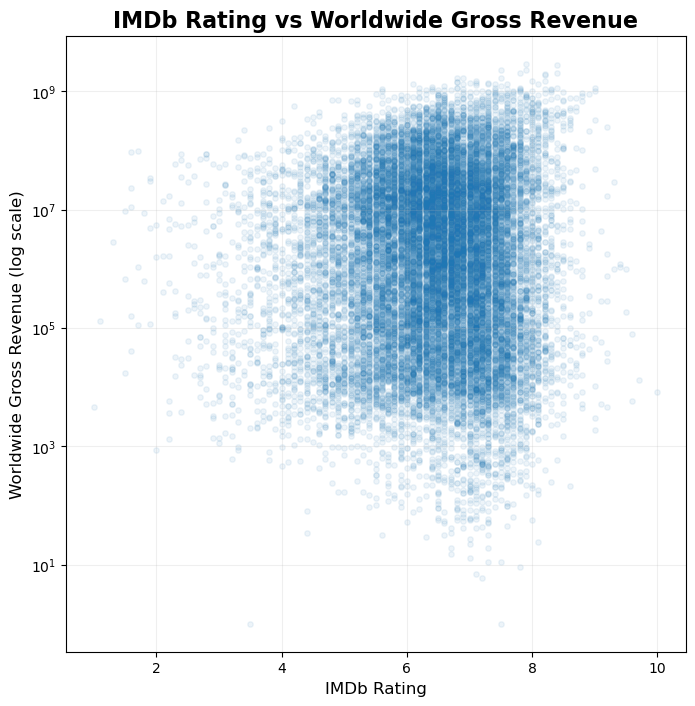

In [28]:
plt.figure(figsize=(8,8))

plt.scatter(
    movies_data['rating'],
    movies_data['gross_worldwide'],
    alpha=0.08,
    s=15
)

plt.yscale('log')

plt.title('IMDb Rating vs Worldwide Gross Revenue',
          fontsize=16,
          fontweight='bold')

plt.xlabel('IMDb Rating', fontsize=12)
plt.ylabel('Worldwide Gross Revenue (log scale)', fontsize=12)

plt.grid(alpha=0.2)

plt.show()

For older movies it's normal to have missing information. But we have 75% of our entries missing data for the budget.
IMDB hides production details for users with paid pro feature.

Our second source of info is going to be Rotten Tomatoes since these two are the most popular for ratings. 

In [29]:
DATA_DIR = Path("data")
DATA_FILE = DATA_DIR / "rotten_tomatoes_movies.csv"

if not DATA_FILE.exists():
    DATA_DIR.mkdir(exist_ok=True)
    raise FileNotFoundError(
        "Dataset not found. Download it from Kaggle and place it in the data/ folder:\n"
        "KAGGLE_LINK_HERE: https://www.kaggle.com/datasets/andrezaza/clapper-massive-rotten-tomatoes-movies-and-reviews/data"
    )

In [30]:
rotten_rating = pd.read_csv(DATA_FILE)

In [31]:
rotten_rating

,rotten_tomatoes_link,movie_title,movie_info,critics_consensus,content_rating,genres,directors,authors,actors,original_release_date,...,production_company,tomatometer_status,tomatometer_rating,tomatometer_count,audience_status,audience_rating,audience_count,tomatometer_top_critics_count,tomatometer_fresh_critics_count,tomatometer_rotten_critics_count
0,m/0814255,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,...,20th Century Fox,Rotten,49.0,149.0,Spilled,53.0,254421.0,43,73,76
1,m/0878835,Please Give,Kate (Catherine Keener) and her husband Alex (...,Nicole Holofcener's newest might seem slight i...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",2010-04-30,...,Sony Pictures Classics,Certified-Fresh,87.0,142.0,Upright,64.0,11574.0,44,123,19
2,m/10,10,"A successful, middle-aged Hollywood songwriter...",Blake Edwards' bawdy comedy may not score a pe...,R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert ...",1979-10-05,...,Waner Bros.,Fresh,67.0,24.0,Spilled,53.0,14684.0,2,16,8
3,m/1000013-12_angry_men,12 Angry Men (Twelve Angry Men),Following the closing arguments in a murder tr...,Sidney Lumet's feature debut is a superbly wri...,NR,"Classics, Drama",Sidney Lumet,Reginald Rose,"Martin Balsam, John Fiedler, Lee J. Cobb, E.G....",1957-04-13,...,Criterion Collection,Certified-Fresh,100.0,54.0,Upright,97.0,105386.0,6,54,0
4,m/1000079-20000_leagues_under_the_sea,"20,000 Leagues Under The Sea","In 1866, Professor Pierre M. Aronnax (Paul Luk...","One of Disney's finest live-action adventures,...",G,"Action & Adventure, Drama, Kids & Family",Richard Fleischer,Earl Felton,"James Mason, Kirk Douglas, Paul Lukas, Peter L...",1954-01-01,...,Disney,Fresh,89.0,27.0,Upright,74.0,68918.0,5,24,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17707,m/zoot_suit,Zoot Suit,Mexican-American gangster Henry Reyna (Daniel ...,NaN,R,"Drama, Musical & Performing Arts",Luis Valdez,Luis Valdez,"Daniel Valdez, Edward James Olmos, Charles Aid...",1981-10-02,...,MCA Universal Home Video,Rotten,56.0,9.0,Upright,74.0,1195.0,2,5,4
17708,m/zootopia,Zootopia,From the largest elephant to the smallest shre...,The brilliantly well-rounded Zootopia offers a...,PG,"Action & Adventure, Animation, Comedy","Byron Howard, Rich Moore, Jared Bush","Jared Bush, Phil Johnston","J.K. Simmons, Kristen Bell, Octavia Spencer, A...",2016-03-04,...,Walt Disney Animation Studios,Certified-Fresh,98.0,291.0,Upright,92.0,101511.0,50,285,7
17709,m/zorba_the_greek,Zorba the Greek,Traveling to inspect an abandoned mine his fat...,NaN,NR,"Action & Adventure, Art House & International,...",NaN,NaN,"Anthony Quinn, Alan Bates, Irene Papas, Lila K...",1964-12-17,...,Fox,Fresh,80.0,10.0,Upright,86.0,7146.0,0,8,2
17710,m/zulu,Zulu,"In 1879, the Zulu nation hands colonial Britis...",Zulu patiently establishes a cast of colorful ...,PG,"Classics, Drama","Cy Endfield, Cyril Endfield","Cy Endfield, John Prebble","Stanley Baker, Jack Hawkins, Ulla Jacobsson, J...",1964-06-17,...,Paramount Pictures,Fresh,96.0,23.0,Upright,91.0,30193.0,6,22,1


IMDb rating (user-driven)
Rotten Tomatoes score (critic-driven)
Box office revenue

tomatometer_count -> Total number of critic reviews
audience_status - > 
"Upright" → audience liked it
"Spilled" → audience disliked it
tomatometer_top_critics_count -> 
major newspapers
famous reviewers
established publications
tomatometer_fresh_critics_count -> Number of positive critic reviews.
tomatometer_rotten_critics_count -> Number of negative critic reviews.

In [33]:
rotten_rating.dtypes

rotten_tomatoes_link                 object
movie_title                          object
movie_info                           object
critics_consensus                    object
content_rating                       object
genres                               object
directors                            object
authors                              object
actors                               object
original_release_date                object
streaming_release_date               object
runtime                             float64
production_company                   object
tomatometer_status                   object
tomatometer_rating                  float64
tomatometer_count                   float64
audience_status                      object
audience_rating                     float64
audience_count                      float64
tomatometer_top_critics_count         int64
tomatometer_fresh_critics_count       int64
tomatometer_rotten_critics_count      int64
dtype: object

In [34]:
rotten_rating['tomatometer_status']

0                 Rotten
1        Certified-Fresh
2                  Fresh
3        Certified-Fresh
4                  Fresh
              ...       
17707             Rotten
17708    Certified-Fresh
17709              Fresh
17710              Fresh
17711             Rotten
Name: tomatometer_status, Length: 17712, dtype: object

### Do audiences or critics predict box office better?

### Does audience size matter?
audience_count vs revenue

### Which genres make the biggest revenue?

In [35]:
movies_data['genres'].value_counts()

genres
['Drama']                                                                                                                                               7635
['Comedy']                                                                                                                                              3499
['Drama', 'Romance']                                                                                                                                    2559
['Comedy', 'Drama']                                                                                                                                     1651
['Documentary']                                                                                                                                         1322
                                                                                                                                                        ... 
['Comedy', 'Family', 'Sci-Fi', 'Sport']            

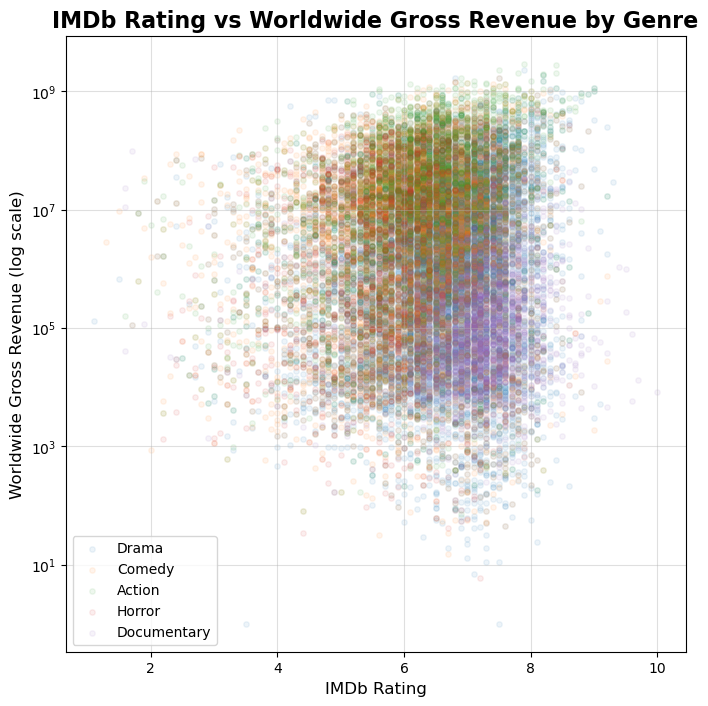

In [36]:
genres = [
    'Drama',
    'Comedy',
    'Action',
    'Horror',
    'Documentary'
]

plt.figure(figsize=(8,8))

for genre in genres:

    genre_data = movies_data[
        movies_data['genres'].str.contains(genre, na=False)
    ]

    plt.scatter(
        genre_data['rating'],
        genre_data['gross_worldwide'],
        alpha=0.08,
        s=15,
        label=genre
    )

plt.yscale('log')

plt.title('IMDb Rating vs Worldwide Gross Revenue by Genre',
          fontsize=16,
          fontweight='bold')

plt.xlabel('IMDb Rating', fontsize=12)
plt.ylabel('Worldwide Gross Revenue (log scale)', fontsize=12)

plt.grid(alpha=0.4)

plt.legend()

plt.show()

### Do specific productions always make relatively big income even if the movie rating is low?